ГУАП | SUAI.
Выполнение первой лабортаорной работы по машинному обучению студентов группы 4431 Чухровой Виктории и Мамутова Данияра.
Вариант работы №8: Набор данных cхемы пирамиды – определение прибыли или убытка. 

Задания лабораторной работы:

Дан многомерный размеченный набор данных. Необходимо выполнить анализ
данных на основе регрессионных моделей в соответствии со следующей
последовательностью этапов.
1. Загрузить необходимые пакеты и библиотеки.
2. Загрузить данные из указанного источника.
3. Выполнить разведочный анализ данных в соответствии с этапами описанными
в файле Этапы проекта машинного обучения в примерах 1/2.pdf:
a. Ознакомление с данными с помощью методов описательной статистики.
b. Выполнить визуализацию данных одномерную для понимания
распределения данных и многомерную для выяснения зависимостей
между признаками.
c. При необходимости выполнить очистку данных одним из методов.
d. При необходимости преобразовать текстовые или категориальные
признаки одним из методов.
e. Проанализировать корреляционную зависимость между признаками.
f. Поэкспериментировать с комбинациями атрибутов. При необходимости
добавить новые атрибуты в набор данных.
g. Выполнить отбор существенных признаков с помощью метода
SelectKBest. Использовать при отборе два критерия: f_regression (см.
пример) и mutual_info_regression (изучить самостоятельно в
документации SelectKBest). Сформировать набор данных из
существенных признаков и добавленных пользовательских признаков.
h. Выполнить масштабирование данных для обоих наборов (исходного и
сформированного) одним из методов по варианту.
4. Анализ выполняется для исходного набора данных (проведена при
необходимости очистка данных и преобразованы текстовые или
категориальные признаки одним из рассмотренных методов),
масштабированного (п.3.h) исходного набора данных, построенного набора
данных (удаление неинформативных, добавление пользовательских
признаков) и масштабированного построенного набора данных. Во всех
наборах данных выделить обучающую, валидационную и тестовую выборки
данных.
5. Сравнить линейную (по варианту) и полиномиальную регрессионные модели на
обучающих и валидационных выборках для всех наборов данных, включая их
масштабированные варианты. Для оценки качества моделей использовать
метрики: корень из среднеквадратичной ошибки, R2. Выбрать лучшую пару
модель-набор.
6. Оценить качество выбранной модели на тестовой выборке выбранного набора.
7. Для лучшей пары модель-набор выполнить Grid поиск лучшего гиперпараметра
регрессионной модели, используя значения оценочных метрик на
валидациооном наборе. Построить графики результатов поиска. Определить
значение лучшего гиперпараметра.
8. Оценить качество модели с определенным лучшим гиперпараметром на
тестовом наборе.
9. Сравнить метрики качества (корень из среднеквадратичной ошибки, R2) лучшей
модели до поиска гиперпараметра и после поиска на тестовой выборке.
Сделать выводы по проведенному анализу.

Исходя из задания мы видим, что начинать надо с первичного анализа данных. Для этого мы будем использовать библиотеки 
pandas, numpy, matplotlib,  которые позволяют легко работать с табличными, скалярными данными и визуализировать их. 

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("V8.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,cost_price,profit_markup,depth_of_tree,sales_commission,profit
0,0,1,3500.0,2,21,1000,-16500
1,1,2,3500.0,2,26,1000,-21500
2,2,3,NaN,2,23,1000,-18500
3,3,4,NaN,3,12,1000,-4000
4,4,5,3500.0,2,12,1000,-7500


Выполняем импорт необходимых библиотек и считываем датасет в переменную df.
Командой ```df.head()``` выводим первые 5 строчек, что бы увидеть, что считывание прошло успешно и ознакомится с самим датасетом.
На первый взгляд кажется, что колонки <Unnamed: 0.1> и <Unnamed: 0> являются порядковыми строками и интереса для анализа не представляют. Так же судя по всему <sales_commission> не имеет уникального значения. Но что бы убедиться в этом надо получить больш информации. 

Вызываем метод ```shape```

In [217]:
df.shape

(500, 7)

Данный метод показывает нам, что датасет имеет 500 строк и 7 колонок.

Далее ознакомимся типом данных каждой из колонок методом ```dtypes```

In [218]:
df.dtypes

Unnamed: 0.1          int64
Unnamed: 0            int64
cost_price          float64
profit_markup         int64
depth_of_tree         int64
sales_commission      int64
profit                int64
dtype: object

Итого имеем 6 колонок int64 и одну колонку float64. Просмотрим содержимое колонок методом ```info()```

In [219]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      500 non-null    int64  
 1   Unnamed: 0        500 non-null    int64  
 2   cost_price        244 non-null    float64
 3   profit_markup     500 non-null    int64  
 4   depth_of_tree     500 non-null    int64  
 5   sales_commission  500 non-null    int64  
 6   profit            500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


Видим, что cost_price имеет только 244 значения non-null, что говорим о том, что возможно придеться обрабатывать пустые значения. 
Далее вызовем метод ```describe()```, что бы получить средние значения и процентили.

In [220]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,cost_price,profit_markup,depth_of_tree,sales_commission,profit
count,500.000000,500.000000,244.0,500.000000,500.000000,500.0,500.000000
mean,249.500000,250.500000,3500.0,3.498000,15.896000,1000.0,-6153.000000
std,144.481833,144.481833,0.0,1.126292,8.095694,0.0,9080.528784
min,0.000000,1.000000,3500.0,2.000000,2.000000,1000.0,-25500.000000
25%,124.750000,125.750000,3500.0,3.000000,9.000000,1000.0,-12500.000000
50%,249.500000,250.500000,3500.0,3.000000,16.000000,1000.0,-6500.000000
75%,374.250000,375.250000,3500.0,5.000000,23.000000,1000.0,500.000000
max,499.000000,500.000000,3500.0,5.000000,30.000000,1000.0,13000.000000


Видим информативную таблицу. Обзор беглым взгялдом показывает, что mean у столбцов cost_price и sales_commission являются константными для всех строк, а значит интереса для анализа никакого не представляют, а значит от них можно избавится. Так же можно заметить, что Unnamed: 0.1 и Unnamed: 0 являются индексами строк, что тоже не несет полезной информации для анализа данных. Есть предположение, что колонка profit имеет сильную карреляционную зависимость от depth_of_tree, а именно чем больше последнее значение - тем больше profit. Но пока все же займемся очисткой датасета. 


In [221]:
c_df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "cost_price", "sales_commission"]).copy()
display(c_df.head())

,profit_markup,depth_of_tree,profit
0,2,21,-16500
1,2,26,-21500
2,2,23,-18500
3,3,12,-4000
4,2,12,-7500


В итоге получаем небольшой "датасетик", целоцисленных int64, который вероятно будет удобнее анализировать. 



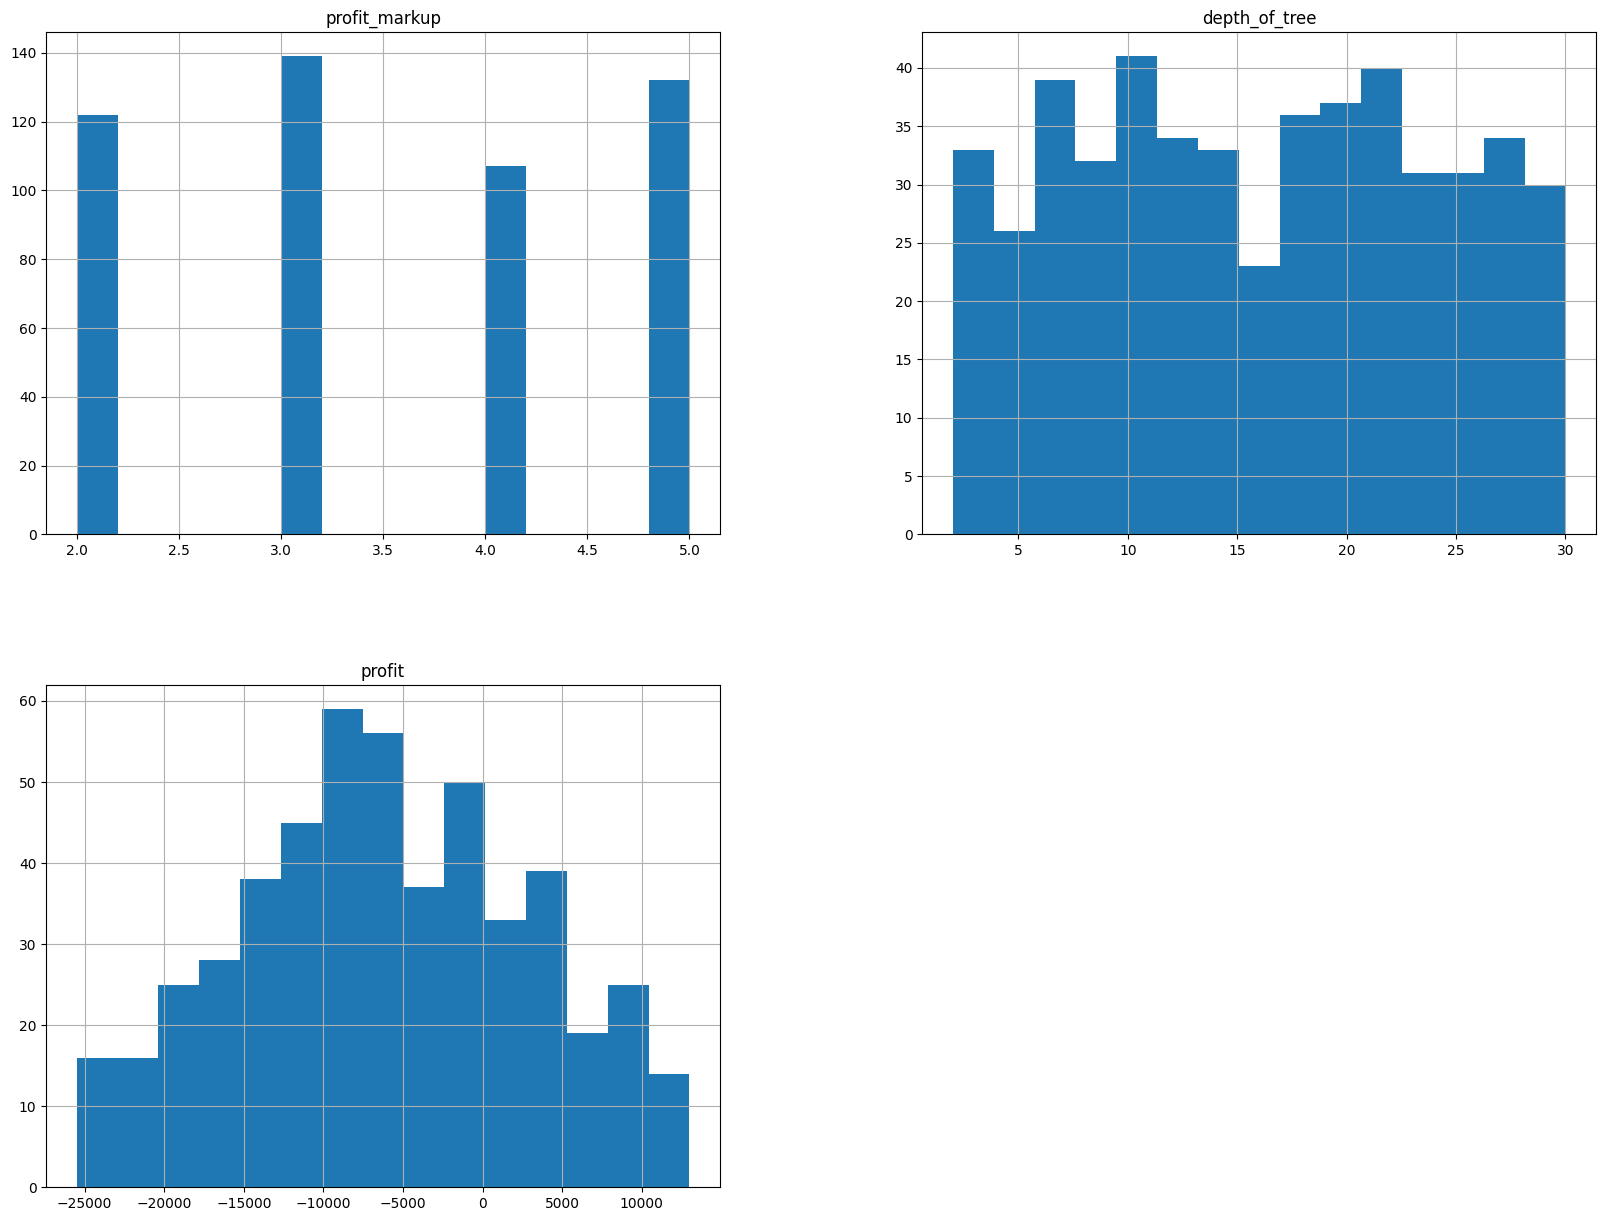

In [222]:

c_df.hist(bins=15, figsize=(20, 15))
plt.show()

Гимтограммы показывают, что чаще всего встречается коофициент markup_profit = 3, значения depth_of_tree равномерно разбросаны от 1 до 30. Но вот больше всего значений profit зафиксированы в убытке от -5000 до -10000. Пока нам сложно сделать какие-то выводы на этом, поэтому продолжим анализ.

Выведем карту карреляций, что бы увидеть зависимость колонок. 

               profit_markup  depth_of_tree    profit
profit_markup       1.000000      -0.021562  0.453341
depth_of_tree      -0.021562       1.000000 -0.900905
profit              0.453341      -0.900905  1.000000


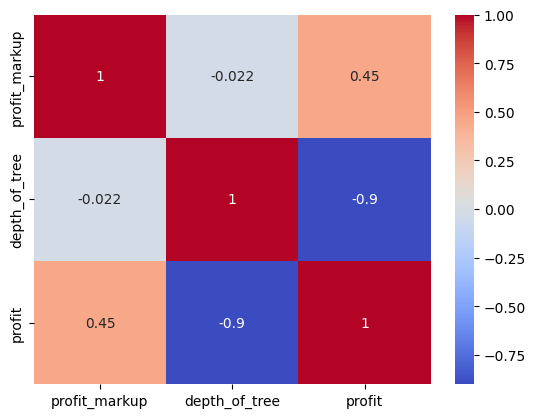

In [223]:
import seaborn as sns

corr_matrix = c_df.corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Как мы и предпологали мы видим сильную зависимость profit от depth_of_tree. Так же наблюдается карреляция profit от profit_markup. И depth_of_tree никак не зависит от profit_markup.

Далее мы решили вывести Матрицу диаграммы рассеяния, что бы визуализировать свзяь между переменными. Используем метод ```sns.pairplot``` из библиотеки seaborn. Так же укажем параметр <kde> что бы увидеть плотность столцов.

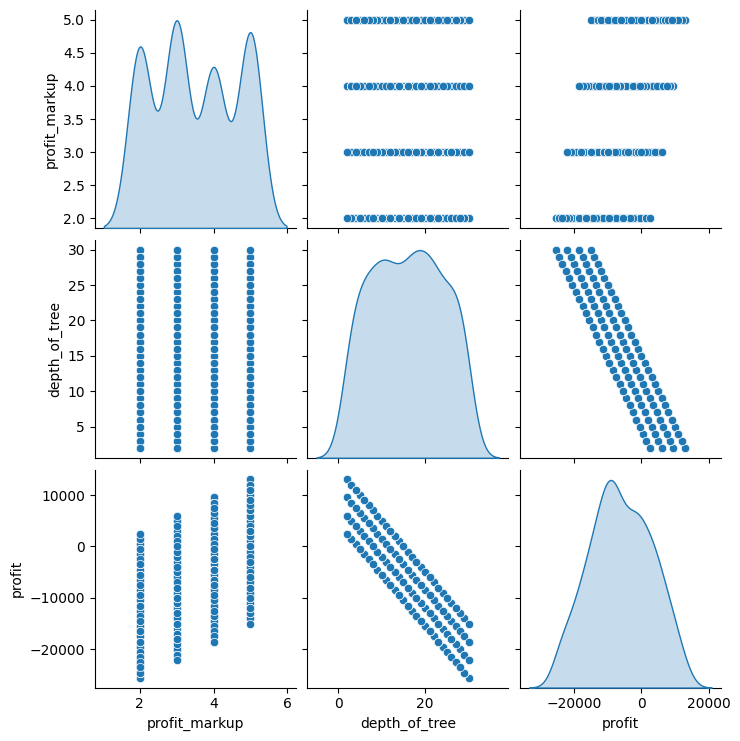

In [224]:
sns.pairplot(c_df, diag_kind='kde')

Данный график показал, что между depth_of_tree и profit есть линейная зависимость. Далее поэкспериментируем с комбинациями атрибутов.

In [225]:
c_df["markup_per_depth"] = c_df["profit_markup"] / (c_df["depth_of_tree"] + 1)
# отношение markup к глубине дерева
c_df["depth_per_markup"] = c_df["depth_of_tree"] / (c_df["profit_markup"] + 1)
# обратное отношение: глубина на единицу markup
c_df["markup_x_depth"] = c_df["profit_markup"] * c_df["depth_of_tree"]
# произведение признаков
c_df["markup_squared"] = c_df["profit_markup"] ** 2
# квадрат markup
c_df["depth_squared"] = c_df["depth_of_tree"] ** 2
# квадрат глубины дерева
display(c_df.head())


,profit_markup,depth_of_tree,profit,markup_per_depth,depth_per_markup,markup_x_depth,markup_squared,depth_squared
0,2,21,-16500,0.090909,7.000000,42,4,441
1,2,26,-21500,0.074074,8.666667,52,4,676
2,2,23,-18500,0.083333,7.666667,46,4,529
3,3,12,-4000,0.230769,3.000000,36,9,144
4,2,12,-7500,0.153846,4.000000,24,4,144


In [226]:
c_df.corr()["profit"].sort_values(ascending=False)

profit              1.000000
markup_per_depth    0.812626
profit_markup       0.453341
markup_squared      0.448754
markup_x_depth     -0.504728
depth_squared      -0.876226
depth_of_tree      -0.900905
depth_per_markup   -0.968519
Name: profit, dtype: float64

Видим сильные корреляционные зависимости у новых атрибутов. Выполним отбор существенных признаков с помощью метода SelectKBest. Используем 2 критерия: f_regression и mutual_info_regression.

Так как мы будем прогонять данные на моделях liner_regression и elasticnet, то нам нужно использовать признаки, полученные по критерию f_regression, так как он определяет линейную зависимость, а mutual_info_regression ищет просто зависимость.

Следующим шагом разделим датасет на 3 части: тренировочную, валидационную и тестовую.

Теперь тоже самое для исходных данных.

In [227]:
from sklearn.model_selection import train_test_split

x = c_df.drop(columns=["profit"])
y = c_df["profit"]

X_new_temp, X_new_test, y_new_temp, y_new_test = train_test_split(x, y, test_size=0.2, random_state=42)    

X_new_train, X_new_val, y_new_train, y_new_val = train_test_split(X_new_temp, y_new_temp, test_size=0.25, random_state=42)

In [228]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
xx = X_new_train.columns

selector = SelectKBest(score_func=f_regression, k=4)
X_new_train = selector.fit_transform(X_new_train, y_new_train)
X_new_val = selector.transform(X_new_val)
X_new_test = selector.transform(X_new_test)
dfscores = pd.DataFrame(selector.scores_, columns=["Score"])
dfcolumns = pd.DataFrame(xx, columns=["Feature"])
feature_scores = pd.concat([dfcolumns, dfscores], axis=1)
feature_scores = feature_scores.sort_values(by="Score", ascending=False)
feature_scores

,Feature,Score
3,depth_per_markup,4535.409373
1,depth_of_tree,1387.155549
6,depth_squared,1030.345403
2,markup_per_depth,565.865674
4,markup_x_depth,109.967448
0,profit_markup,78.286739
5,markup_squared,75.834204


In [229]:
selector_m = SelectKBest(mutual_info_regression, k=4)
x_new_m = selector_m.fit_transform(x, y)
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "MI Score": selector_m.scores_
})

feature_scores.sort_values("MI Score", ascending=False)

,Feature,MI Score
3,depth_per_markup,3.287109
2,markup_per_depth,3.234552
4,markup_x_depth,3.074112
1,depth_of_tree,2.426670
6,depth_squared,2.336257
0,profit_markup,0.635637
5,markup_squared,0.601914


In [230]:
x_old = c_df.drop(columns=["profit", "markup_per_depth", "depth_per_markup", "markup_x_depth", "markup_squared", "depth_squared"])
y = c_df["profit"]

X_temp, X_test, y_temp, y_test = train_test_split(x_old, y, test_size=0.2, random_state=42)    

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

Далее идет импорт заранее подготовленного класса ElasticNetModelLab1.

В нем реализован pipeline для ElsticNet и ElsticNet с PolynomialFeatures (Полиномиальная регрессия), вывод метрик и графиков. 


ElasticNet Regression_new_data_normalizer ( alpha=0.05, l1_ratio=0.5)
Scaling: normalizer
--------------------------------------------------
Train RMSE: 8084.2342 | R2: 0.25590184
Val   RMSE: 8272.1979 | R2: 0.21602860
Test  RMSE: 6905.7367 | R2: 0.20964421


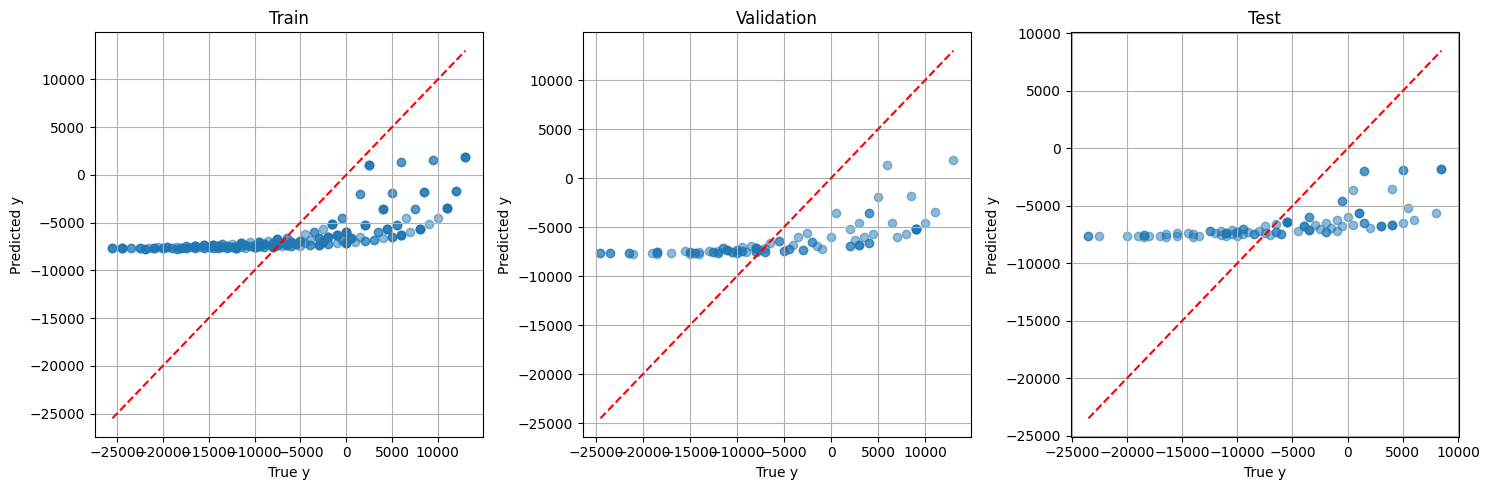


ElasticNet Regression_new_data_normalizer_polynomial ( alpha=0.05, l1_ratio=0.5, degree=2)
Scaling: normalizer
--------------------------------------------------
Train RMSE: 6141.7227 | R2: 0.57052996
Val   RMSE: 6286.4783 | R2: 0.54723459
Test  RMSE: 5661.6578 | R2: 0.46876113


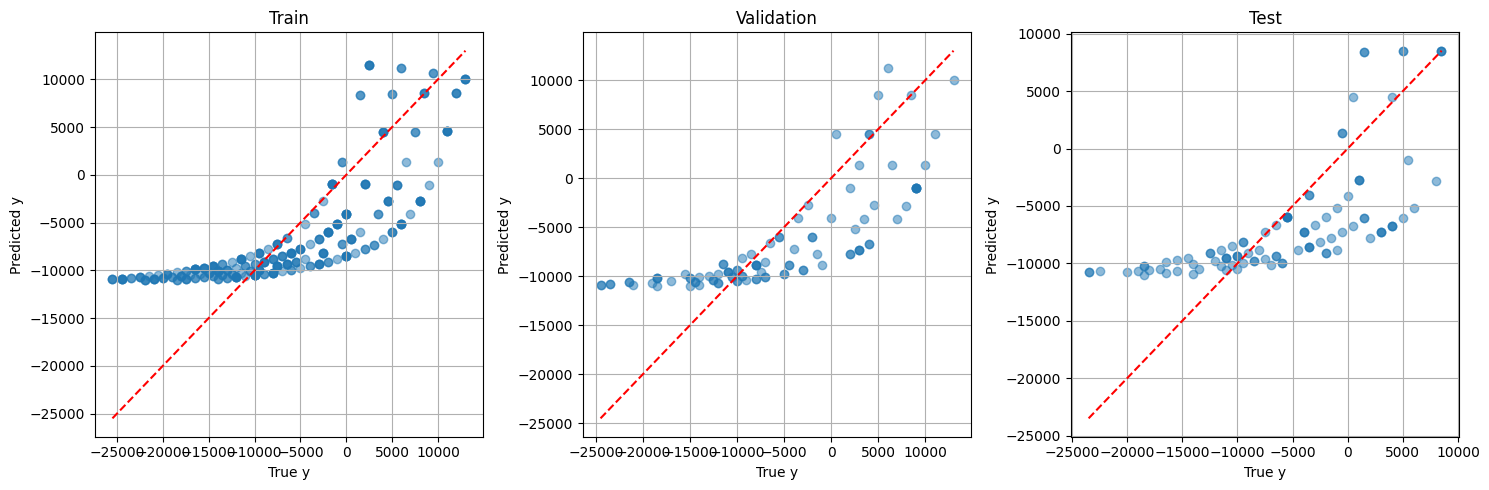

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalizer', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"norm norm: {'l1', 'l2', 'max'}, default='l2'The norm to use to normalize each non zero sample. If norm='max'is used, values will be rescaled by the maximum of the absolutevalues.",'l2'
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array or a scipy.sparseCSR matrix).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",15
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05


In [231]:
import importlib
import Lab_1 as Lab_1

importlib.reload(Lab_1)

from Lab_1 import ElasticNetModelLab1
elastic_model_new_nr = ElasticNetModelLab1(name="ElasticNet Regression_new_data_normalizer ( alpha=0.05, l1_ratio=0.5)", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test, scaling="normalizer")
elastic_model_new_nr.learn()
elastic_model_new_nr_pl = ElasticNetModelLab1(name="ElasticNet Regression_new_data_normalizer_polynomial ( alpha=0.05, l1_ratio=0.5, degree=2)", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test, scaling="normalizer", degree=15)
elastic_model_new_nr_pl.learn()

Выведенные графики и метрики дают не утешительные итоги. Как можем заметить, полиномиальная регрессия дает улучшения результатов метрик. Методом проб было выявленно, что degree=15 наиболее оптимальный вариант в соотношении времени обучения и результата. Хотя все же слишком высокий кооэфициент.

Далее попробуем вывести результаты для начального датасета.


ElasticNet Regression_normalizer ( alpha=0.05, l1_ratio=0.5)
Scaling: normalizer
--------------------------------------------------
Train RMSE: 5196.3726 | R2: 0.69256519
Val   RMSE: 5119.9746 | R2: 0.69967326
Test  RMSE: 4716.1228 | R2: 0.63138515


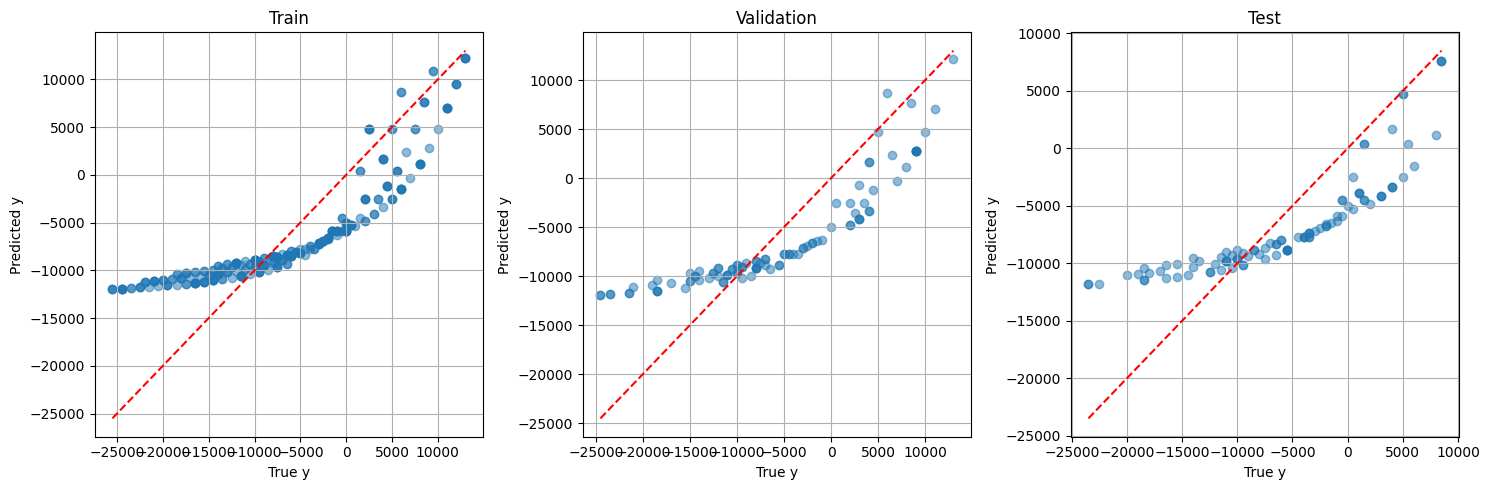


ElasticNet Regression_normalizer_polynomial ( alpha=0.05, l1_ratio=0.5)
Scaling: normalizer
--------------------------------------------------
Train RMSE: 3711.1856 | R2: 0.84318854
Val   RMSE: 3460.2103 | R2: 0.86282866
Test  RMSE: 3459.9110 | R2: 0.80160420


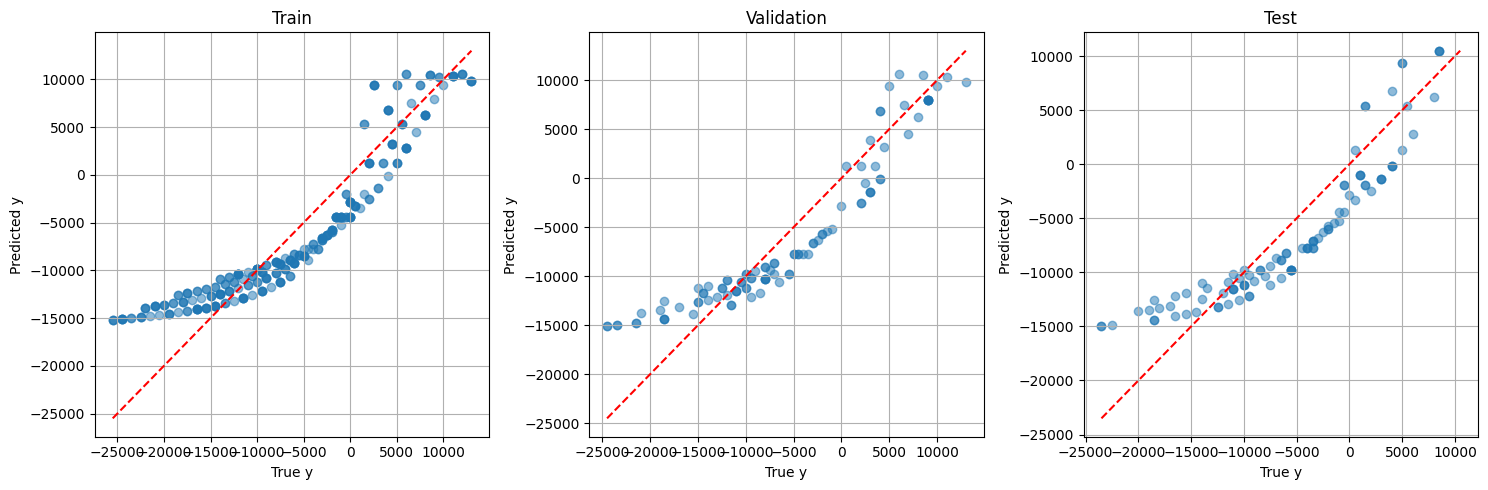

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalizer', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"norm norm: {'l1', 'l2', 'max'}, default='l2'The norm to use to normalize each non zero sample. If norm='max'is used, values will be rescaled by the maximum of the absolutevalues.",'l2'
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array or a scipy.sparseCSR matrix).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05


In [232]:
elastic_model_nr = ElasticNetModelLab1(name="ElasticNet Regression_normalizer ( alpha=0.05, l1_ratio=0.5)", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, scaling="normalizer")
elastic_model_nr.learn()
elastic_model_nr_pl = ElasticNetModelLab1(name="ElasticNet Regression_normalizer_polynomial ( alpha=0.05, l1_ratio=0.5)", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, scaling="normalizer", degree=5)
elastic_model_nr_pl.learn()

Как мы видим результаты у начального dataframe намного лучше, но все же полиномиальная регрессия показывает лучший результат.

Конечно можно было бы удовлетвориться этим результатом, но мы все же поэкспериментируем еще и попробуем обучить без масштабирования.


ElasticNet Regression_new_data ( alpha=0.05, l1_ratio=0.5)
Scaling: None
--------------------------------------------------
Train RMSE: 1558.4039 | R2: 0.97234889
Val   RMSE: 1699.2480 | R2: 0.96691951
Test  RMSE: 1501.1610 | R2: 0.96265288


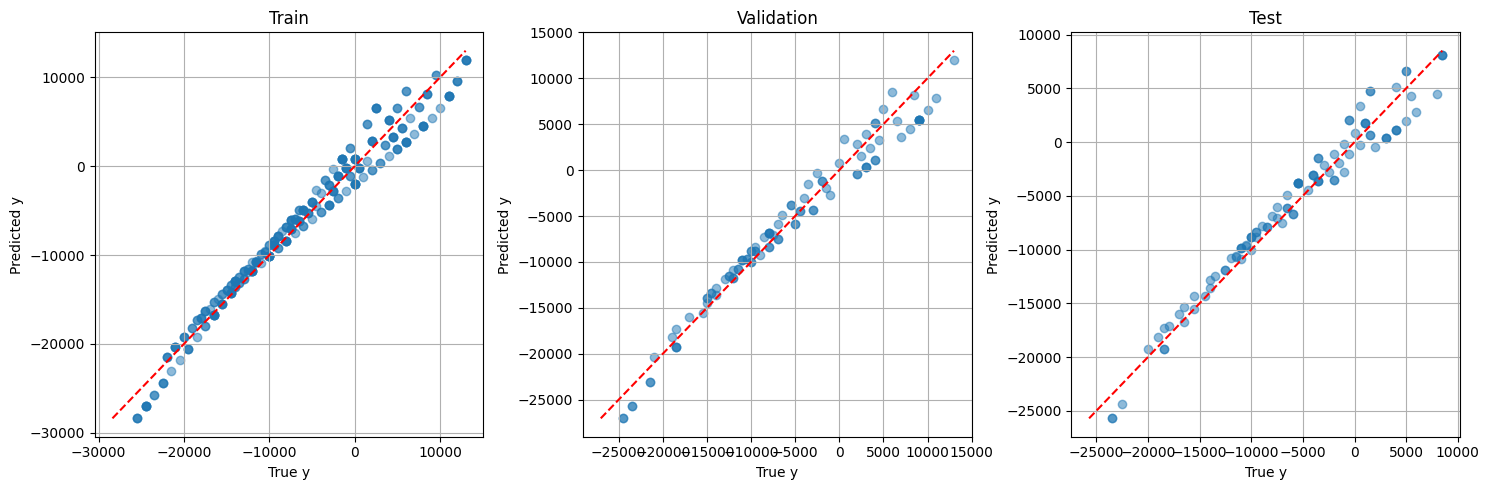


ElasticNet Regression_new_data_polynomial ( alpha=0.05, l1_ratio=0.5)
Scaling: None
--------------------------------------------------
Train RMSE: 40.3688 | R2: 0.99998145
Val   RMSE: 32.5003 | R2: 0.99998790
Test  RMSE: 35.5868 | R2: 0.99997901


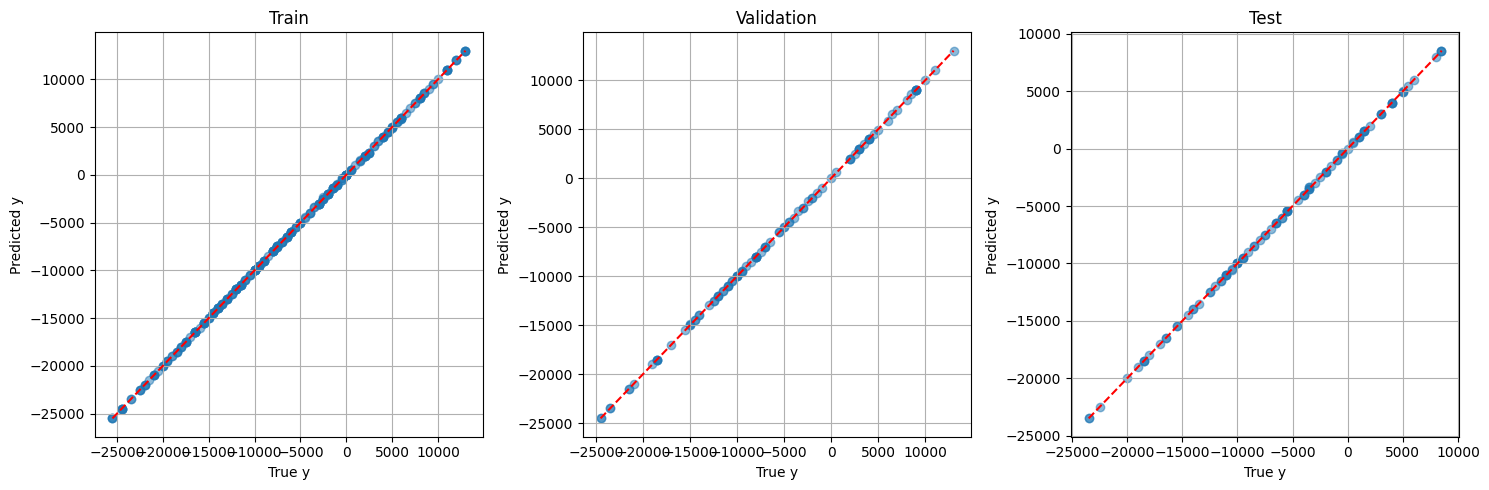

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('elasticnet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",15
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True


In [233]:

elastic_model_new = ElasticNetModelLab1(name="ElasticNet Regression_new_data ( alpha=0.05, l1_ratio=0.5)", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test)
elastic_model_new.learn()
elastic_model_new_pl = ElasticNetModelLab1(name="ElasticNet Regression_new_data_polynomial ( alpha=0.05, l1_ratio=0.5)", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test, degree=15)
elastic_model_new_pl.learn()

Этот резульат уже оправдывает наши усилия. ElasticNet без масштабирования показал прекрасный результат, но полиномиальность достигла почти иделаьных показателей RMSE и R2

Теперь тоже самое с начальномым датасетом.


ElasticNet Regression ( alpha=0.05, l1_ratio=0.5)
Scaling: None
--------------------------------------------------
Train RMSE: 76.1694 | R2: 0.99993394
Val   RMSE: 78.0467 | R2: 0.99993021
Test  RMSE: 73.6533 | R2: 0.99991009


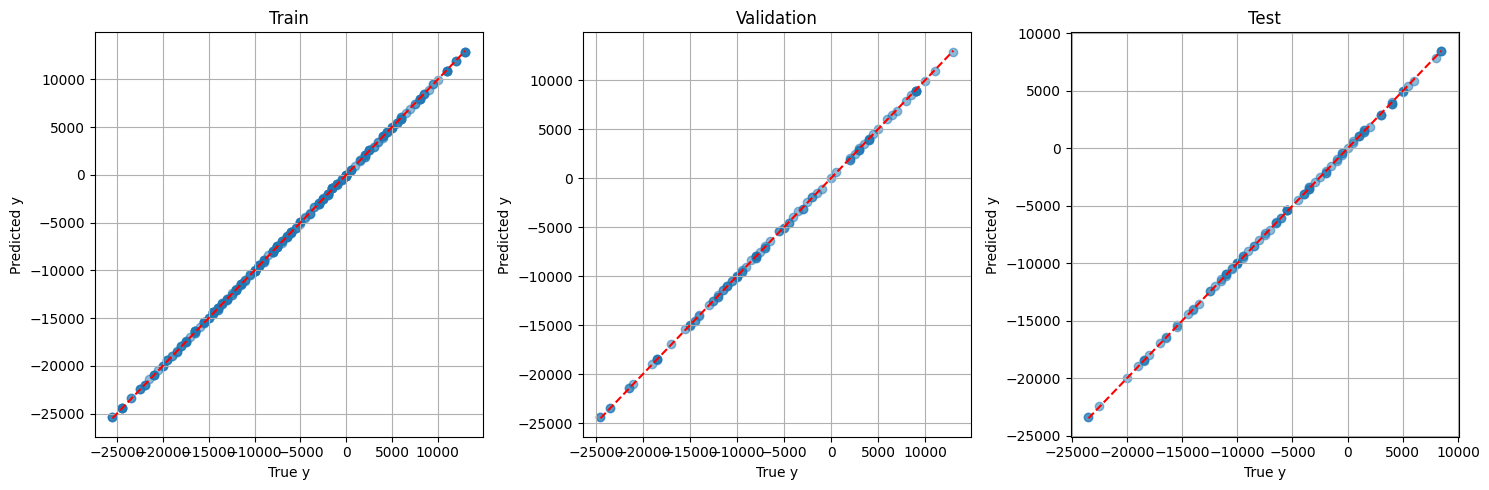


ElasticNet Regression_polynomial ( alpha=0.05, l1_ratio=0.5)
Scaling: None
--------------------------------------------------
Train RMSE: 270.0158 | R2: 0.99916990
Val   RMSE: 254.4952 | R2: 0.99925798
Test  RMSE: 284.2361 | R2: 0.99866106


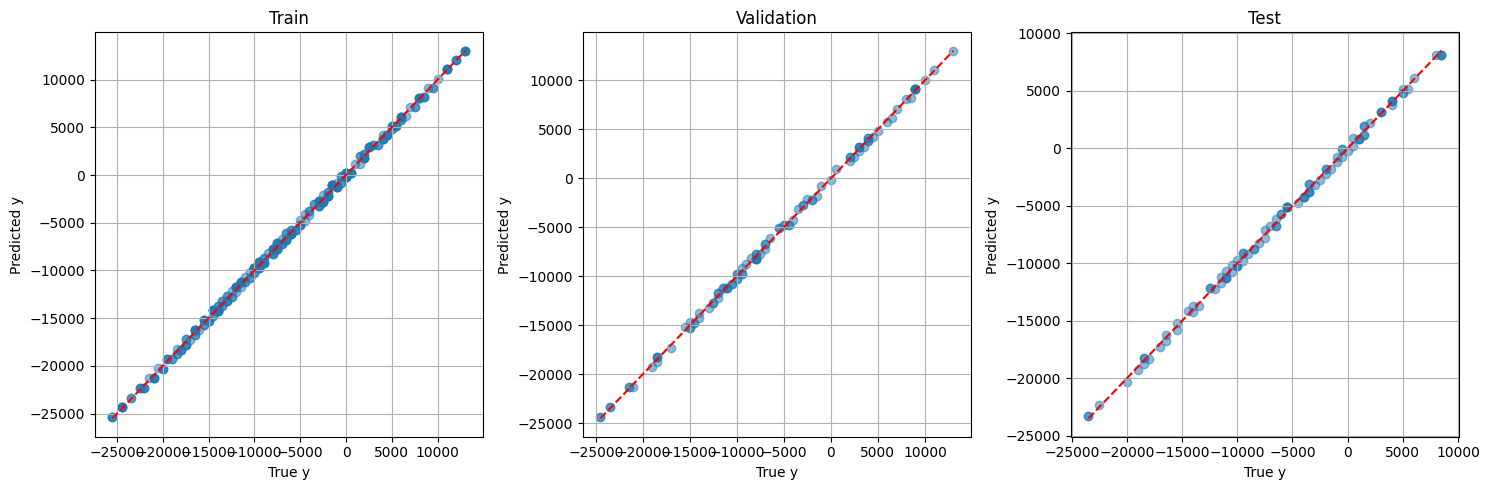

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('elasticnet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True


In [234]:
elastic_model = ElasticNetModelLab1(name="ElasticNet Regression ( alpha=0.05, l1_ratio=0.5)", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)
elastic_model.learn()
elastic_model_pl = ElasticNetModelLab1(name="ElasticNet Regression_polynomial ( alpha=0.05, l1_ratio=0.5)", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, degree=2)
elastic_model_pl.learn()

Почти те же результаты. Однако тут по R2 и RMSE метрикам лидирует простая ElasticNet без полиномиальности.

Возможно получится еще больше улучшить результаты, если применим StandartScaler.


ElasticNet Regression_new_data_standard ( alpha=0.05, l1_ratio=0.5)
Scaling: standard
--------------------------------------------------
Train RMSE: 1444.4087 | R2: 0.97624622
Val   RMSE: 1588.9173 | R2: 0.97107582
Test  RMSE: 1404.4262 | R2: 0.96731109


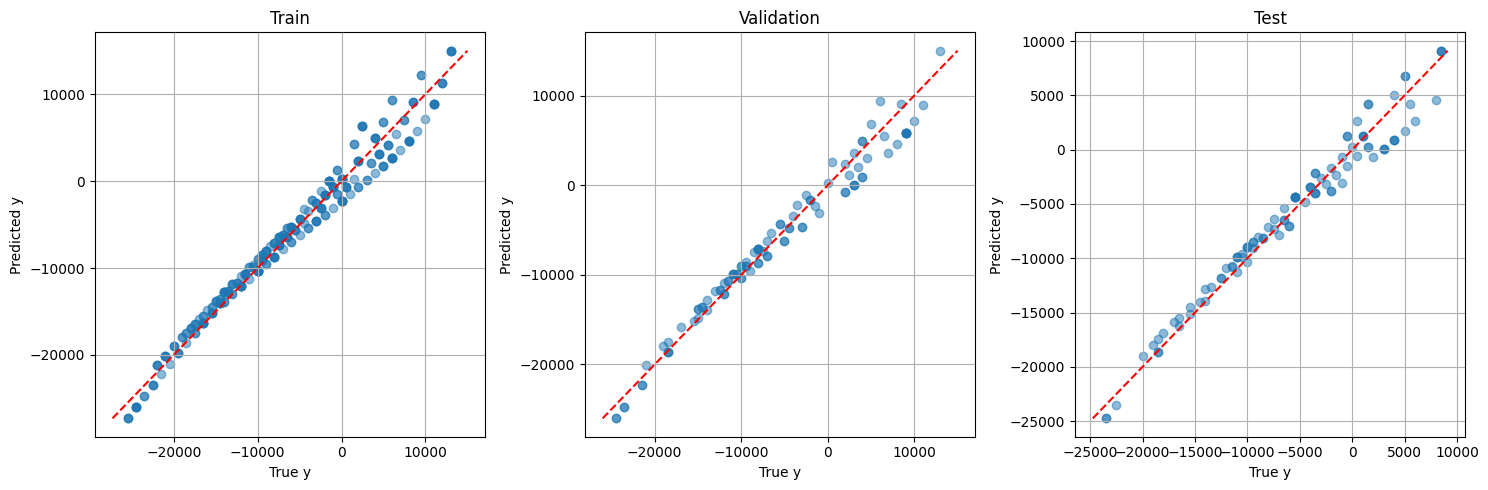

/home/korolevskii-korol/Ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.806e+08, tolerance: 2.635e+06
  model = cd_fast.enet_coordinate_descent(



ElasticNet Regression_new_data_standard_polynomial ( alpha=0.05, l1_ratio=0.5)
Scaling: standard
--------------------------------------------------
Train RMSE: 572.8376 | R2: 0.99626393
Val   RMSE: 652.1073 | R2: 0.99512812
Test  RMSE: 639.9405 | R2: 0.99321294


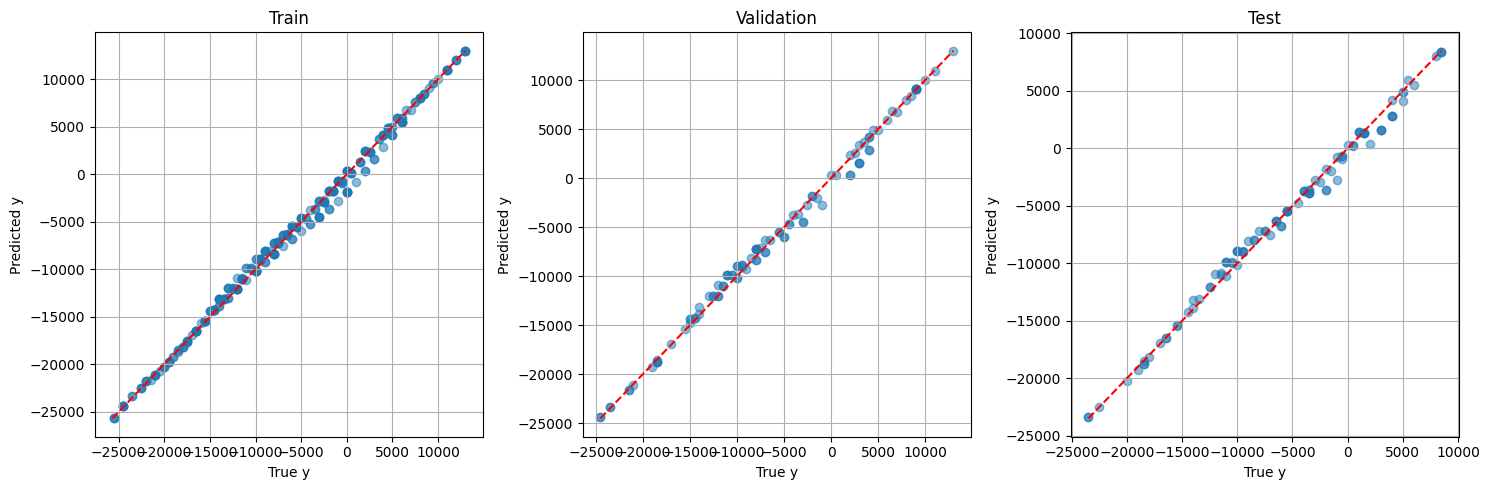

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [235]:
elastic_model_new_st = ElasticNetModelLab1(name="ElasticNet Regression_new_data_standard ( alpha=0.05, l1_ratio=0.5)", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test, scaling="standard")
elastic_model_new_st.learn()
elastic_model_new_st_pl = ElasticNetModelLab1(name="ElasticNet Regression_new_data_standard_polynomial ( alpha=0.05, l1_ratio=0.5)", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test, scaling="standard", degree=5)
elastic_model_new_st_pl.learn()


ElasticNet Regression_standard ( alpha=0.05, l1_ratio=0.5)
Scaling: standard
--------------------------------------------------
Train RMSE: 222.0500 | R2: 0.99943862
Val   RMSE: 221.2513 | R2: 0.99943917
Test  RMSE: 184.6640 | R2: 0.99943485


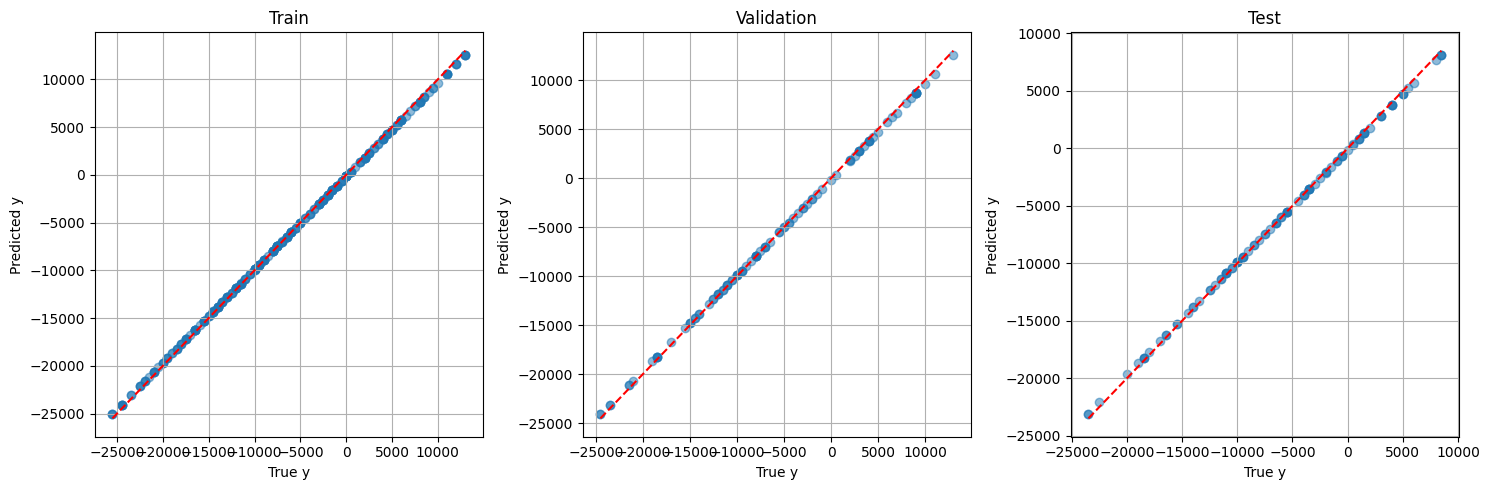


ElasticNet Regression_standard_polynomial ( alpha=0.05, l1_ratio=0.5)
Scaling: standard
--------------------------------------------------
Train RMSE: 550.0631 | R2: 0.99655509
Val   RMSE: 585.1654 | R2: 0.99607702
Test  RMSE: 625.1689 | R2: 0.99352265


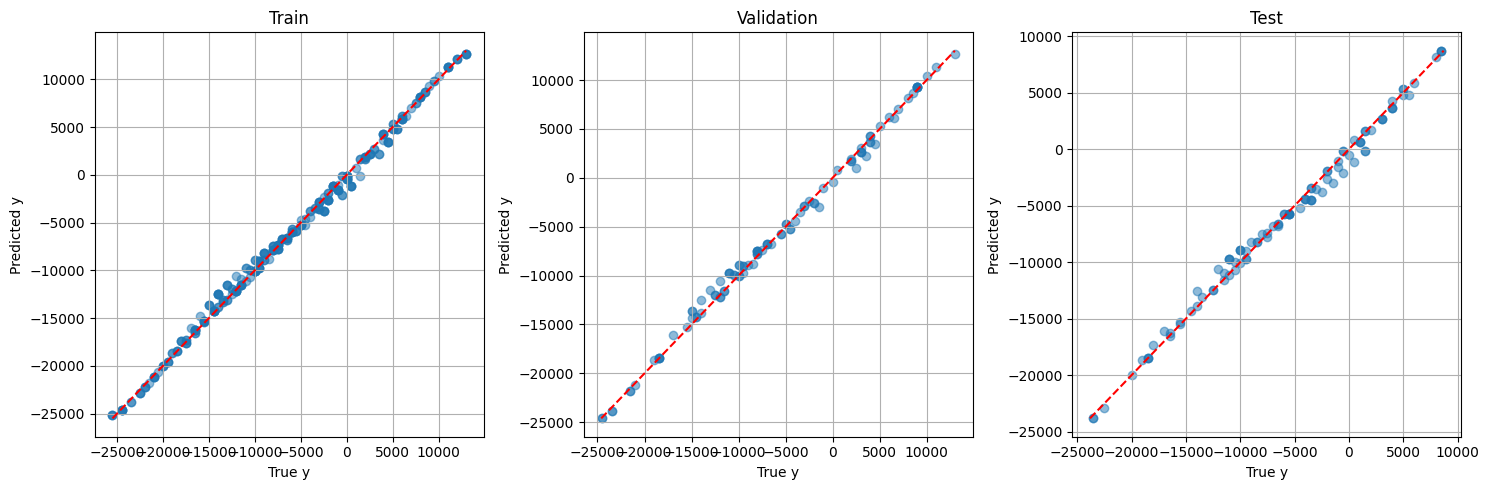

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [236]:
elastic_model_st = ElasticNetModelLab1(name="ElasticNet Regression_standard ( alpha=0.05, l1_ratio=0.5)", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, scaling="standard")
elastic_model_st.learn()
elastic_model_st_pl = ElasticNetModelLab1(name="ElasticNet Regression_standard_polynomial ( alpha=0.05, l1_ratio=0.5)", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, scaling="standard", degree=5)
elastic_model_st_pl.learn()

Результаты на лицо по сравнению с Normalized. Вероятно это объясняется тем, что масштабирование этим критерием плохо сказывается на сильнейший признак deph_of_tree.

Далее вызовем метод, который покажет наиболее оптимальлную пару "Датасет - Модель".

In [237]:
ElasticNetModelLab1.show_best_r2()

,name,train_mse,val_mse,test_mse,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,ElasticNet Regression_new_data_polynomial ( al...,1.629638e+03,1.056272e+03,1.266417e+03,40.368770,32.500344,35.586756,0.999981,0.999988,0.999979
6,"ElasticNet Regression ( alpha=0.05, l1_ratio=0.5)",5.801779e+03,6.091287e+03,5.424813e+03,76.169407,78.046697,73.653333,0.999934,0.999930,0.999910
10,"ElasticNet Regression_standard ( alpha=0.05, l...",4.930619e+04,4.895214e+04,3.410081e+04,222.049965,221.251307,184.664044,0.999439,0.999439,0.999435
7,"ElasticNet Regression_polynomial ( alpha=0.05,...",7.290851e+04,6.476781e+04,8.079017e+04,270.015766,254.495209,284.236121,0.999170,0.999258,0.998661
11,ElasticNet Regression_standard_polynomial ( al...,3.025694e+05,3.424185e+05,3.908361e+05,550.063083,585.165373,625.168892,0.996555,0.996077,0.993523
9,ElasticNet Regression_new_data_standard_polyno...,3.281429e+05,4.252439e+05,4.095239e+05,572.837592,652.107251,639.940539,0.996264,0.995128,0.993213
8,ElasticNet Regression_new_data_standard ( alph...,2.086317e+06,2.524658e+06,1.972413e+06,1444.408705,1588.917326,1404.426198,0.976246,0.971076,0.967311
4,"ElasticNet Regression_new_data ( alpha=0.05, l...",2.428623e+06,2.887444e+06,2.253484e+06,1558.403910,1699.247963,1501.161019,0.972349,0.966920,0.962653
3,ElasticNet Regression_normalizer_polynomial ( ...,1.377290e+07,1.197306e+07,1.197098e+07,3711.185580,3460.210340,3459.911021,0.843189,0.862829,0.801604
2,"ElasticNet Regression_normalizer ( alpha=0.05,...",2.700229e+07,2.621414e+07,2.224181e+07,5196.372628,5119.974589,4716.122847,0.692565,0.699673,0.631385


И на первом месте оказывается ElasticNet с полиномиальностью для комбинированного датасета.  Довольно сложно объяснить причины таких результатов.

Далее попробуем найти лучший гиперпараметр для этой пары. Для этого воспользуемся методом GridSearchCV.

/home/korolevskii-korol/Ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.254e+06, tolerance: 2.066e+06
  model = cd_fast.enet_coordinate_descent(
/home/korolevskii-korol/Ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.236e+06, tolerance: 2.194e+06
  model = cd_fast.enet_coordinate_descent(
/home/korolevskii-korol/Ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Best parameters: {'elasticnet__alpha': 0.0001, 'elasticnet__l1_ratio': 0.9}
Best R2 score: 1.0000
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.119013      0.025864         0.005060        0.000600   
1        0.151018      0.038060         0.005129        0.000965   
2        0.175018      0.039477         0.006810        0.002012   
3        0.147759      0.016901         0.004394        0.000327   
4        0.115942      0.013619         0.004363        0.000184   
5        0.216563      0.036970         0.004482        0.000550   
6        0.249257      0.042568         0.005881        0.002341   
7        0.240046      0.033516         0.004113        0.000130   
8        0.213944      0.040266         0.003813        0.000187   
9        0.123998      0.024953         0.004676        0.000818   
10       0.789029      0.135629         0.005506        0.001212   
11       0.413129      0.218744         0.004662        0.000490   
12       0.179409 

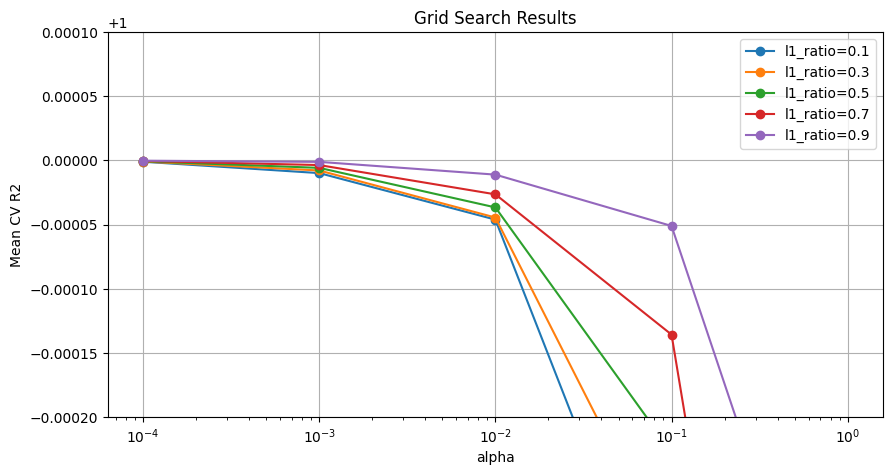

In [238]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
pipe = Pipeline([
            ("poly", PolynomialFeatures(degree = 5)),
            ("elasticnet", ElasticNet(max_iter=10000))
        ])

param_grid = {

    "elasticnet__alpha": [
        0.0001,
        0.001,
        0.01,
        0.1,
        1
    ],

    "elasticnet__l1_ratio": [
        0.1,
        0.3,
        0.5,
        0.7,
        0.9
    ]
}
grid_search = GridSearchCV(
    estimator=pipe,

    param_grid=param_grid,

    scoring="r2",

    cv=5,

    n_jobs=-1
)
grid_search.fit(X_new_train, y_new_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R2 score: {grid_search.best_score_:.4f}")
results = pd.DataFrame(
    grid_search.cv_results_
)

print(results)
plt.figure(figsize=(10, 5))

for l1 in param_grid["elasticnet__l1_ratio"]:

    subset = results[
        results["param_elasticnet__l1_ratio"] == l1
    ]

    plt.plot(
        subset["param_elasticnet__alpha"],
        subset["mean_test_score"],
        marker="o",
        label=f"l1_ratio={l1}"
    )

plt.ylim(0.9998, 1.0001)

plt.xscale("log")

plt.xlabel("alpha")
plt.ylabel("Mean CV R2")

plt.title("Grid Search Results")

plt.legend()

plt.grid(True)

plt.show()

Для выбранной лучшей пары модель-набор был выполнен Grid Search для подбора оптимальных гиперпараметров модели ElasticNet. В процессе поиска рассматривались различные значения параметров alpha и l1_ratio. Параметр alpha отвечает за силу регуляризации модели, а l1_ratio определяет соотношение между L1- и L2-регуляризацией.
На графике представлены результаты Grid Search: по оси X отложены значения параметра alpha в логарифмическом масштабе, а по оси Y — среднее значение коэффициента детерминации R², полученное при кросс-валидации. Каждая линия соответствует определённому значению параметра l1_ratio.
По результатам анализа установлено, что наилучшее качество модели достигается при малых значениях alpha. При увеличении коэффициента регуляризации качество модели постепенно ухудшается, так как слишком сильная регуляризация начинает ограничивать веса модели и снижает её способность точно описывать данные.
Оптимальными гиперпараметрами модели стали:
- alpha = 0.0001
- l1_ratio = 0.9
При данных параметрах модель показала максимальное значение коэффициента детерминации R², близкое к 1, что свидетельствует о высокой точности предсказаний и хорошем качестве регрессии.
Также из графика видно, что увеличение параметра l1_ratio позволяет модели медленнее терять качество при росте alpha, однако наилучшие результаты всё равно достигаются при минимальных значениях коэффициента регуляризации.
Таким образом, Grid Search позволил определить оптимальные гиперпараметры модели ElasticNet и повысить качество модели на валидационных данных.

Далее выполним оценку качества модели с определенными лучшими гиперпараметрами на тестовом наборе.



Best ElasticNet Model
Scaling: None
--------------------------------------------------
Train RMSE: 3.4695 | R2: 0.99999986
Val   RMSE: 4.2199 | R2: 0.99999980
Test  RMSE: 4.0865 | R2: 0.99999972


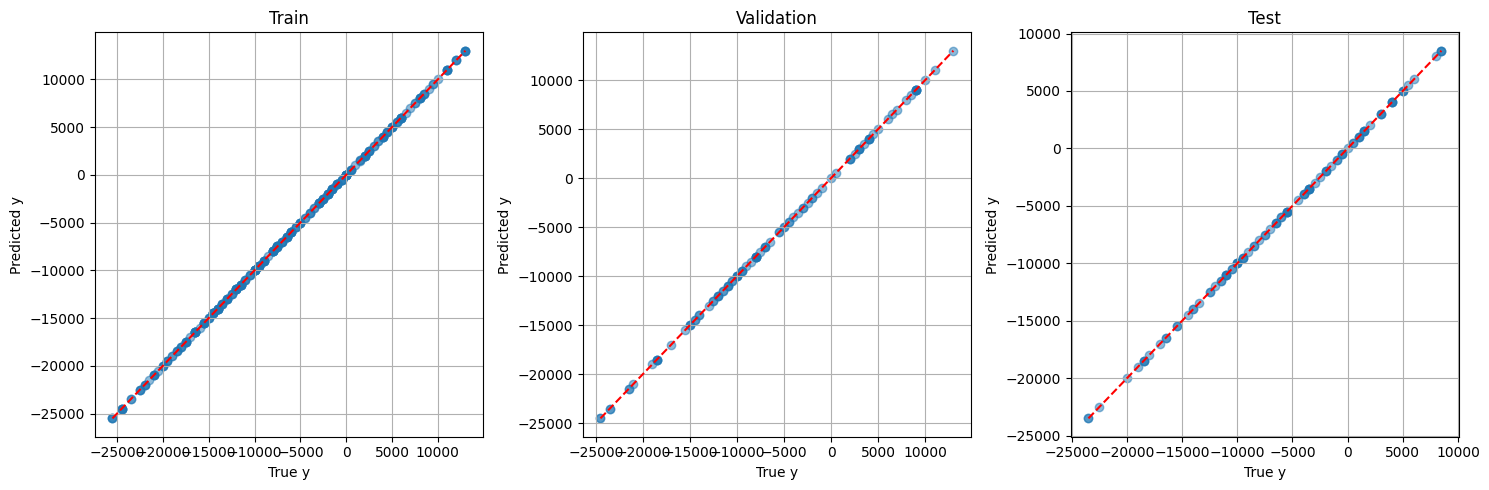

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('elasticnet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.0001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.9
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True


In [246]:
best_model = ElasticNetModelLab1(name="Best ElasticNet Model", X_train=X_new_train, y_train=y_new_train, X_val=X_new_val, y_val=y_new_val, X_test=X_new_test, y_test=y_new_test, degree=5, alpha=0.0001, l1_ratio=0.9)
best_model.learn()

Мы получили превосходный результат с отклонием RMSE = 4 для тестововй выборки и R2 ≈ 1 с точностью до 8 знаков после запятой. Сравним его с результатом до поиска Grid Search.

In [247]:
print("Just model with polynomial features:")
elastic_model_new_pl.print_metrics()

print(f"\n{'-' * 50}\n")

print("Best Model with Hyperparameters:")
best_model.print_metrics()

Just model with polynomial features:

ElasticNet Regression_new_data_polynomial ( alpha=0.05, l1_ratio=0.5)
Scaling: None
--------------------------------------------------
Train RMSE: 40.3688 | R2: 0.99998145
Val   RMSE: 32.5003 | R2: 0.99998790
Test  RMSE: 35.5868 | R2: 0.99997901

--------------------------------------------------

Best Model with Hyperparameters:

Best ElasticNet Model
Scaling: None
--------------------------------------------------
Train RMSE: 3.4695 | R2: 0.99999986
Val   RMSE: 4.2199 | R2: 0.99999980
Test  RMSE: 4.0865 | R2: 0.99999972


Не сильно видна разница в метрике R2, однако RMSE удалось снизить практически в 10 раз. В итоге мы нашли превосходную пару модель-набор. 

ВЫВОД.
В ходе лабораторной работы был выполнен анализ набора данных для задачи регрессии. На этапе предварительной обработки были удалены неинформативные признаки, содержащие индексы строк и константные значения. Также были добавлены новые пользовательские признаки, отражающие отношения, произведения и квадраты исходных признаков.
Корреляционный анализ показал, что наиболее сильная связь с целевой переменной profit наблюдается у признаков, связанных с глубиной дерева. При этом зависимость имеет отрицательный характер: с увеличением depth_of_tree значение profit уменьшается, то есть убыток возрастает. Дополнительно был выполнен отбор существенных признаков с помощью SelectKBest с критериями f_regression и mutual_info_regression.
В рамках моделирования были исследованы регрессионные модели ElasticNet в линейном и полиномиальном вариантах. Сравнение проводилось на исходном наборе данных и на наборе после отбора признаков, а также для разных вариантов масштабирования: без масштабирования, с Normalizer и со StandardScaler. Для оценки качества использовались метрики RMSE и R² на обучающей, валидационной и тестовой выборках.
По результатам экспериментов было установлено, что использование Normalizer заметно ухудшает качество модели. Это связано с тем, что Normalizer масштабирует строки, а не признаки по столбцам, из-за чего теряется важная информация об абсолютных значениях признаков. Лучшие результаты были получены для исходного набора данных без масштабирования при использовании полиномиальной модели ElasticNet.
Для выбранной лучшей пары модель-набор был выполнен Grid Search по гиперпараметрам alpha и l1_ratio. По результатам поиска оптимальными значениями оказались alpha = 0.0001 и l1_ratio = 0.9. При этих параметрах модель показала наилучшее качество на тестовой выборке: значение RMSE значительно уменьшилось, а R² стал практически равен 1.
Таким образом, подбор гиперпараметров позволил существенно улучшить качество регрессионной модели. Наилучшей моделью в рамках проведённого анализа стала полиномиальная ElasticNet-регрессия на исходном наборе данных без масштабирования с параметрами alpha = 0.0001 и l1_ratio = 0.9. Полученные значения метрик свидетельствуют о высокой точности аппроксимации данных и хорошем качестве построенной модели.